# 019 - QAOA - Vesion II 

## 1.00 Admin  

#### 1.10 Libraries

In [17]:
# 0.00 Core imports
import numpy as np

from qiskit import transpile
from qiskit.circuit.library import NLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import n_local

from qiskit_ibm_runtime import (
    Batch,
    SamplerV2,
    QiskitRuntimeService,
)

# for circuit graphics 
import pylatexenc

# for the environment report 
import environment as envir 
from tabulate import tabulate 


#### 1.10 Environment 

In [2]:
data, headers = envir.environment_state()
print(tabulate(data, headers=headers))

System/Library           Version
-----------------------  ---------
Python                   3.11.15
numpy                    2.4.3
torch                    2.10.0
matplotlib               3.10.8
seaborn                  0.13.2
qiskit                   2.2.0
qiskit_machine_learning  0.9.0
qiskit_optimization      0.7.0
qiskit_ibm_runtime       0.45.1
pylatexenc               2.10
qiskit_algorithms        0.4.0
yfinance                 1.2.0
qiskit_aer               0.15.1
qiskit-finance           0.4.1


#### 1.20 Notebook Parameters 

In [3]:
n_qubits = 4 

print_flag = True 

#### 1.30 Platform Authentication

In [4]:
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    instance="ptc_work", 
)

#### 1.40 Backend Selection (Least Busy) 

In [11]:
# Filter for real devices (exclude simulators) and those that are operational
backends = service.backends(
    simulator=False,
    operational=True
)

# Sort by queue length
least_busy = sorted(backends, key=lambda b: b.status().pending_jobs)[0]

backend = least_busy
print(f"Using least busy backend: {backend.name}")
print(f"Qubits: {backend.num_qubits}") 
print(f"Pending jobs: {backend.status().pending_jobs}")

Using least busy backend: ibm_fez
Qubits: 156
Pending jobs: 0


### 2.00 Circuit Build 

#### 2.10 Data  

In [12]:
# 1.00 Problem size
num_assets = 4

# 1.10 QUBO coefficients from your printed quadratic program

linear = {
    0: -0.1,
    1: -0.2,
    2: -0.15,
    3: -0.18
}

quadratic = {
    (0, 1): -0.01,
    (0, 2):  0.004,
    (0, 3): -0.002,
    (1, 2): -0.002,
    (1, 3):  0.004,
    (2, 3):  0.002
}

diag = {
    0: 0.0025,
    1: 0.02,
    2: 0.0115,
    3: 0.009
}

In [13]:
# 1.20 Build Hamiltonian: x_i = (1 - Z_i)/2 mapping

def build_portfolio_hamiltonian(num_qubits=4):
    paulis = []
    coeffs = []

    def z_term(i, j=None):
        # Qiskit uses little-endian ordering in labels
        n = num_qubits
        if j is None:
            label = ['I'] * n
            label[n - 1 - i] = 'Z'
            return ''.join(label)
        else:
            label = ['I'] * n
            label[n - 1 - i] = 'Z'
            label[n - 1 - j] = 'Z'
            return ''.join(label)

    # Linear terms: x_i = (1 - Z_i)/2
    for i, c in linear.items():
        paulis.append("I" * num_qubits)
        coeffs.append(c * 0.5)

        paulis.append(z_term(i))
        coeffs.append(-c * 0.5)

    # Quadratic diagonal terms: x_i^2 = x_i
    for i, c in diag.items():
        paulis.append("I" * num_qubits)
        coeffs.append(c * 0.5)

        paulis.append(z_term(i))
        coeffs.append(-c * 0.5)

    # Quadratic cross terms: x_i x_j = (1 - Z_i - Z_j + Z_i Z_j)/4
    for (i, j), c in quadratic.items():
        paulis.append("I" * num_qubits)
        coeffs.append(c * 0.25)

        paulis.append(z_term(i))
        coeffs.append(-c * 0.25)

        paulis.append(z_term(j))
        coeffs.append(-c * 0.25)

        paulis.append(z_term(i, j))
        coeffs.append(c * 0.25)

    return SparsePauliOp(paulis, coeffs)

In [14]:
hamiltonian = build_portfolio_hamiltonian(num_qubits=num_assets)
hamiltonian

SparsePauliOp(['IIII', 'IIIZ', 'IIII', 'IIZI', 'IIII', 'IZII', 'IIII', 'ZIII', 'IIII', 'IIIZ', 'IIII', 'IIZI', 'IIII', 'IZII', 'IIII', 'ZIII', 'IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IIII', 'IIIZ', 'IZII', 'IZIZ', 'IIII', 'IIIZ', 'ZIII', 'ZIIZ', 'IIII', 'IIZI', 'IZII', 'IZZI', 'IIII', 'IIZI', 'ZIII', 'ZIZI', 'IIII', 'IZII', 'ZIII', 'ZZII'],
              coeffs=[-0.05   +0.j,  0.05   +0.j, -0.1    +0.j,  0.1    +0.j, -0.075  +0.j,
  0.075  +0.j, -0.09   +0.j,  0.09   +0.j,  0.00125+0.j, -0.00125+0.j,
  0.01   +0.j, -0.01   +0.j,  0.00575+0.j, -0.00575+0.j,  0.0045 +0.j,
 -0.0045 +0.j, -0.0025 +0.j,  0.0025 +0.j,  0.0025 +0.j, -0.0025 +0.j,
  0.001  +0.j, -0.001  +0.j, -0.001  +0.j,  0.001  +0.j, -0.0005 +0.j,
  0.0005 +0.j,  0.0005 +0.j, -0.0005 +0.j, -0.0005 +0.j,  0.0005 +0.j,
  0.0005 +0.j, -0.0005 +0.j,  0.001  +0.j, -0.001  +0.j, -0.001  +0.j,
  0.001  +0.j,  0.0005 +0.j, -0.0005 +0.j, -0.0005 +0.j,  0.0005 +0.j])

#### 2.20 Ansatz 

In [18]:
# 2.00 Ansatz
ansatz = n_local(
    num_qubits=num_assets,
    rotation_blocks=["ry"],
    entanglement_blocks="cz",
    entanglement="linear",
    reps=2
)

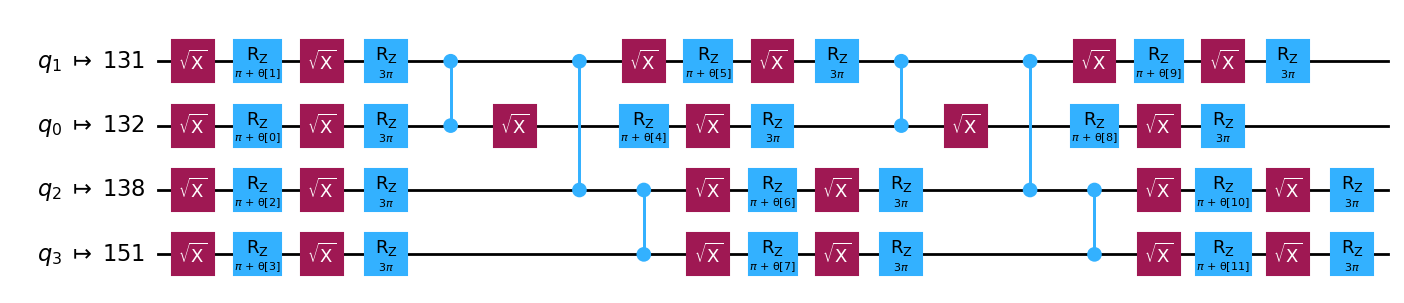

In [19]:
# 2.10 Transpile ansatz for target backend
ansatz = transpile(
    ansatz,
    backend=backend,
    optimization_level=3
)

ansatz.draw(output="mpl")

#### 2.4 Generate Samples 

In [20]:
# 3.00 Random parameter sampling setup
num_samples = 256  # number of parameter vectors to evaluate
num_params = ansatz.num_parameters

rng = np.random.default_rng(123)
thetas_list = [2 * np.pi * rng.random(num_params) for _ in range(num_samples)]

### 3.00 Job Submission 

In [22]:
# 4.00 Batch submission
jobs = []

with Batch(backend=backend) as batch:

    sampler = SamplerV2(
        mode=batch,
        options={"execution": {"shots": 2048}}
    )

    for theta in thetas_list:
        bound = ansatz.bind_parameters(theta)
        job = sampler.run(
            circuits=[bound],
            observables=[hamiltonian]
        )
        jobs.append(job)

# 4.10 After exiting the Batch context, all jobs are submitted
len(jobs)

ValidationError: 2 validation errors for SamplerOptions
execution.SamplerExecutionOptionsV2.shots
  Unexpected keyword argument [type=unexpected_keyword_argument, input_value=2048, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/unexpected_keyword_argument
execution.is-instance[Dict]
  Input should be an instance of Dict [type=is_instance_of, input_value={'init_qubits': Unset, 'r...': Unset, 'shots': 2048}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/is_instance_of